In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from IPython.display import display, Markdown

Dans toute cette étude, nous nous intéressons aux résultats obtenus par le "bloc de gauche" aux élections municipales de 2014 et 2020. 
Nous considérons ici que ce bloc correspond à au groupe Europe Ecologie-Les Verts (LVEC), au groupe Ecologiste (LECO), au groupe Union de la Gauche (LUG), au groupe Divers Gauche (LDVG), au groupe (LSOC) et au groupe Liste du Parti de Gauche (LPG).

In [177]:
#on définit donc le array suivant

BLOC_GAUCHE_ECOLO = [
    'LVEC', 'LVECE',# Europe Ecologie-Les Verts
    'LECO',  # Ecologiste
    'LUG',   # Union de la Gauche
    'LDVG',   # Divers Gauche
    'LSOC',	 #Parti socialiste
    'LPG'	#Liste du Parti de Gauche
]

# --- DÉTECTION AUTOMATIQUE DE LA RACINE ---
CURRENT_DIR = os.getcwd()

# Si on est dans le dossier 'notebooks', on remonte d'un cran
if os.path.basename(CURRENT_DIR) == 'notebooks':
    PROJECT_ROOT = os.path.dirname(CURRENT_DIR)
# Sinon (si on est déjà à la racine via le main), on reste là
else:
    PROJECT_ROOT = CURRENT_DIR

# --- DÉFINITION DES CHEMINS RELATIFS ---
# On construit le chemin à partir de la racine trouvée dynamiquement
RAW_ELEC_DIR = os.path.join(PROJECT_ROOT, 'Data', 'raw_elections')


### Création de la base de donnée relatives aux résultats de l'élection communale de 2020
Pour des fins de comparabilité, nous avons choisit de concentrer notre analyse sur les communes de France métropolitaine (donc sans les données des DROMs, COMs, Terres australes et de Nouvelle Calédonie).Pour chaque commune, nous avons identifié la nuance politique de la liste victorieuse en restructurant la base des résultats détaillés. Cette donnée n'est disponible que pour les communes de plus de 3 500 habitants 

In [178]:
display(Markdown("""### Création de la base de donnée relatives aux résultats de l'élection communale de 2020 
Pour des fins de comparabilité, nous avons choisit de concentrer notre analyse sur les communes de France métropolitaine 
(donc sans les données des DROMs, COMs, Terres australes et de Nouvelle Calédonie).Pour chaque commune, nous avons identifié 
la nuance politique de la liste victorieuse en restructurant la base des résultats détaillés. Cette donnée n'est disponible que 
pour les communes de plus de 3 500 habitants.

Ci-dessous un aperçu de la base importée :"""))

### Création de la base de donnée relatives aux résultats de l'élection communale de 2020 
Pour des fins de comparabilité, nous avons choisit de concentrer notre analyse sur les communes de France métropolitaine 
(donc sans les données des DROMs, COMs, Terres australes et de Nouvelle Calédonie).Pour chaque commune, nous avons identifié 
la nuance politique de la liste victorieuse en restructurant la base des résultats détaillés. Cette donnée n'est disponible que 
pour les communes de plus de 3 500 habitants.

Ci-dessous un aperçu de la base importée :

In [179]:
#Nous faisons le choix d'enlever les DROM, les COM, les Terres australes et la Nouvelle-Calédonie : code de département None ou supérieurs à 900.
#Le département de corse du sud sera noté 201 au lieu de 2A et haute corse 202 au lieu de 2B

# 1. Chemin relatif plutôt qu'absolu
# On utilise la variable RAW_ELEC_DIR définie précédemment
file_path_2020 = os.path.join(RAW_ELEC_DIR, '2020-06-29-resultats-t2-communes-de-1000-hab-et-plus.xlsx')

resultats_2020 = pd.read_excel(
    file_path_2020,
    header=0,
    dtype={'Code de la commune': str, 'Code du département': str}
)
#Filtrage aux communes métropolitaines
resultats_2020['Code du département'] = resultats_2020['Code du département'].replace({'2A': '201', '2B': '202'})
resultats_2020['Code du département'] = pd.to_numeric(resultats_2020['Code du département'], errors='coerce')
resultats_2020 = resultats_2020[resultats_2020['Code du département'] < 900]

#Création d'un code commune (qui est le code INSEE de la commune)
resultats_2020['Code commune'] = (
    resultats_2020['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2020['Code de la commune'].astype(str).str.zfill(3)
)

#Aperçu de la base
resultats_2020.head(5)

,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Code commune
0,1.0,Ain,034,Belley,5757,2877,49.97,2880,50.03,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01034
1,1.0,Ain,160,Ferney-Voltaire,3798,2280,60.03,1518,39.97,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01160
2,1.0,Ain,194,Jassans-Riottier,4357,2689,61.72,1668,38.28,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01194
3,1.0,Ain,249,Miribel,6847,4064,59.35,2783,40.65,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01249
4,1.0,Ain,354,Saint-Genis-Pouilly,5015,3108,61.97,1907,38.03,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01354


In [180]:
# Pour chaque commune, nous récupérons le vainqueur de l'élection qui à remporté par définition
# le plus de voix (comme il s'agit de la base des résultats communaux au second tour). 
# A la différence d'une base de données où seuls les gagnants sont indiqués, cela
# nous permet de connaitre le pourcentage de voix exprimé en sa faveur.

#Informations concervées sur la commune
commune_cols = ['Code commune', 'Libellé de la commune']

#Bloc de colonnes de chacun des candidats
candidate_fields = [
    'N.Pan.', 'Code Nuance', 'Sexe', 'Nom', 'Prénom', 'Liste',
    'Sièges / Elu', 'Sièges Secteur', 'Sièges CC', 'Voix', '% Voix/Ins', '% Voix/Exp'
]

# Identification des blocs candidats et traitement pour chaque commune
cols = list(resultats_2020.columns)
start = cols.index('N.Pan.') 
k = len(candidate_fields) # nombre de colonnes par candidat à l'élection
nblocks = (len(cols) - start) // k

#Création d'une base de donnée plus "longue", où chaque ligne ne contient plus que les informations pour un seul candidat
dfs = []
for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2020[commune_cols + blk_cols].copy()
    cand_df.columns = commune_cols + candidate_fields
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs.append(cand_df)

long_df_2020 = pd.concat(dfs, ignore_index=True)

#Tri par commune par nombre de voix descendant
long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

#Aperçu
long_df_sorted.head(5)


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90


In [181]:
# Ajout d'une colonne pour sélectionner le gagnant avec un booléen "winner"
idx = long_df_2020.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df_2020["winner"] = "no"
long_df_2020.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)

,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01,no
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70,no
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90,no


In [182]:
# Sélection du vainqueur pour chaque commune, avec son résultat en pourcentage
long_df_2020['% Voix/Exp'] = pd.to_numeric(long_df_2020['% Voix/Exp'], errors='coerce')
winners_2020 = long_df_2020.loc[long_df_2020.groupby('Code commune')['% Voix/Exp'].idxmax()].copy()

winners_2020['D_elec_2020'] = np.where(
    winners_2020["Code Nuance"].isna(),
    np.nan,
    winners_2020["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de communes conservées : {len(winners_2020)}")
display(winners_2020.head())

Nombre de communes conservées : 1340


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2020
1340,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes,0.0
1341,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes,0.0
3573,01194,Jassans-Riottier,4.0,LDVD,M,REVERCHON,Jean-Pierre,JASSANS LA FORCE D'AGIR ENSEMBLE,23.0,0.0,5.0,856.0,19.65,52.16,yes,0.0
3,01249,Miribel,1.0,LDVD,M,GAITET,Jean-Pierre,"Miribel pour tous, Miribel à tous",23.0,0.0,11.0,1391.0,20.32,50.73,yes,0.0
1344,01354,Saint-Genis-Pouilly,2.0,LDVG,M,BERTRAND,Hubert,"SAINT-GENIS-POUILLY, C'EST VOUS",25.0,0.0,5.0,867.0,17.29,46.12,yes,1.0


In [183]:
#exportations
export_2020 = os.path.join(RAW_ELEC_DIR, 'elec_2020_all.csv')
long_df_sorted.to_csv(export_2020, index=False, sep=',', encoding='utf-8', na_rep='NA')

In [184]:
display(Markdown("""La base traitée nous permet d'avoir le vainqueur, sa nuance politique et son pourcentage de voix exprimées. Cette base est ensuite exportée pour pouvoir être mieux traitée par la suite. """))

La base traitée nous permet d'avoir le vainqueur, sa nuance politique et son pourcentage de voix exprimées. Cette base est ensuite exportée pour pouvoir être mieux traitée par la suite. 

### Création de la base de donnée relatives aux résultats de l'élection communale de 2014
Comme pour la base précédente, une étape de filtrage est d'abord nécessaire sur la base importée, une adaptation de la base au traitement, on restreint les variables présentes à celles qui nous intéresse et on détermine ensuite l'élu pour chaque commune avec sa nuance politique.

In [185]:
display(Markdown("""### Création de la base de donnée relatives aux résultats de l'élection communale de 2014
Comme pour la base précédente, une étape de filtrage est d'abord nécessaire sur la base importée, et on détermine ensuite l'élu pour chaque commune avec sa nuance politique.

Ci-dessous un aperçu de la base importée avant traitement :"""))

### Création de la base de donnée relatives aux résultats de l'élection communale de 2014
Comme pour la base précédente, une étape de filtrage est d'abord nécessaire sur la base importée, et on détermine ensuite l'élu pour chaque commune avec sa nuance politique.

Ci-dessous un aperçu de la base importée avant traitement :

In [186]:
# --- CHARGEMENT ROBUSTE base 2014 ---
file_path_2014 = os.path.join(RAW_ELEC_DIR, 'muni-2014-resultats-com-1000-et-plus-t2.xlsx')

resultats_2014 = pd.read_excel(
    file_path_2014, 
    header=0,
    dtype={'Code de la commune': str, 'Code du département': str} # Force le format texte
)
resultats_2014.head(5)

,Date de l'export,Code du département,Type de scrutin,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,...,Unnamed: 623,Unnamed: 624,Unnamed: 625,Unnamed: 626,Unnamed: 627,Unnamed: 628,Unnamed: 629,Unnamed: 630,Unnamed: 631,Unnamed: 632
0,2014-03-31 09:33:41,1,LI2,AIN,4,Ambérieu-en-Bugey,8198,3619,44.14,4579,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-03-31 09:33:41,1,LI2,AIN,7,Ambronay,1770,434,24.52,1336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-03-31 09:33:41,1,LI2,AIN,34,Belley,5680,1557,27.41,4123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-03-31 09:33:41,1,LI2,AIN,160,Ferney-Voltaire,4070,1882,46.24,2188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-03-31 09:33:41,1,LI2,AIN,185,Hauteville-Lompnes,2252,803,35.66,1449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [187]:
# Remplacement des codes Corse
resultats_2014['Code du département'] = resultats_2014['Code du département'].replace({'2A': '201', '2B': '202'})

# Convertir en Int64 et forcer NaN si non convertible
resultats_2014['Code du département'] = pd.to_numeric(resultats_2014['Code du département'], errors='coerce').astype('Int64')

# Supprimer les DROM/COM/TAAF/Nouvelle-Calédonie (codes >900 ou NaN)
resultats_2014 = resultats_2014.dropna(subset=['Code du département'])
resultats_2014 = resultats_2014[resultats_2014['Code du département'] <= 900]

# Créer un code commune unique : 2 chiffres département + 3 chiffres commune
resultats_2014['Code commune'] = (
    resultats_2014['Code du département'].astype(str).str.zfill(2) +
    resultats_2014['Code de la commune'].astype(str).str.zfill(3)
    )


In [188]:
df = resultats_2014.copy()

commune_cols = ['Code commune', 'Libellé de la commune']
candidate_fields = ['Code Nuance','Sexe','Nom','Prénom','Liste',
                    'Sièges / Elu','Sièges Secteur','Sièges CC','Voix','% Voix/Ins','% Voix/Exp']
k = len(candidate_fields)

cols = list(df.columns)
start = cols.index('Code Nuance')
nblocks = (len(cols) - start) // k

dfs = []
for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k:
        continue
    cand_df = df[commune_cols + blk_cols].copy()
    cand_df = cand_df.rename(columns=dict(zip(blk_cols, candidate_fields)))
    cand_df = cand_df[cand_df['Nom'].notna() & (cand_df['Nom'].str.strip() != '')]
    dfs.append(cand_df)

long_df = pd.concat(dfs, ignore_index=True)


In [189]:
idx = long_df.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df["winner"] = "no"
long_df.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)



In [190]:
# Sélection du vainqueur pour chaque commune, avec son résultat en pourcentage
winners_2014 = long_df_sorted.loc[long_df_sorted['winner']=='yes'].reset_index(drop=True)

# Le candidat appartient-il au bloc de gauche ?
winners_2014['D_elec_2014'] = np.where(
    winners_2014["Code Nuance"].isna(),
    np.nan,
    winners_2014["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de communes conservées : {len(winners_2014)}")
display(winners_2014.head(5))

display(Markdown("""Ci-dessous un aperçu de la base après filtrage et traitement :"""))

Nombre de communes conservées : 1675


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2014
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes,0.0
1,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes,1.0
2,01034,Belley,LDVD,M,JIMENEZ,Christian,BELLEY NOUVEL HORIZON 2014,22,0.0,14.0,2029.0,35.72,51.17,yes,0.0
3,01160,Ferney-Voltaire,LDVD,M,RAPHOZ,Daniel,FERNEY-VOLTAIRE VALEURS COMMUNES,22,0.0,4.0,1075.0,26.41,50.45,yes,0.0
4,01185,Hauteville-Lompnes,LUDI,M,ARGENTI,Bernard,OSONS L'AVENIR,22,0.0,6.0,815.0,36.19,61.28,yes,0.0


Ci-dessous un aperçu de la base après filtrage et traitement :

In [191]:
export_2014 = os.path.join(RAW_ELEC_DIR, 'elec_2014_all.csv')
long_df_sorted.to_csv(export_2014, index=False, sep=',', encoding='utf-8', na_rep='NA')

### Statistiques descriptives sur les bases de données des élections municipales
Pour rappel, nous avons importé les résultats des élections communales de 2020 pour les communes de plus de 3500 habitants, les résultats de 2014. Commençons à comparer ces 2 bases.

In [192]:
# --- 1. DÉFINITION DES DONNÉES (Pour le traitement) ---

# Dictionnaire complet avec les libellés pour l'affichage propre
# Structure : Bloc -> {Code: Libellé}
definition_blocs = {
    " BLOC GAUCHE & ÉCOLO": {
        'LVECE': 'Europe Ecologie-Les Verts',
        'LVEC': 'Europe Ecologie-Les Verts',
        'LECO': 'Ecologiste',
        'LUG': 'Union de la Gauche',
        'LDVG': 'Divers Gauche',
        'LSOC': 'Parti socialiste',
        'LPG': 'Parti de Gauche'
    },
    " BLOC EXTRÊME GAUCHE": {
        'LEXG': 'Extrême gauche',
        'LCOM': 'Parti communiste français',
        'LFI': 'La France insoumise',
        'LRDG': 'Parti radical de gauche',
        'LFG': 'Front de Gauche'
    },
    " BLOC CENTRE": {
        'LREM': 'La République en marche',
        'LMDM': 'Modem',
        'LUC': 'Union du centre',
        'LDVC': 'Divers centre'
    },
    " BLOC DROITE": {
        'LLR': 'Les Républicains',
        'LUD': 'Union de la droite',
        'LDVD': 'Divers droite',
        'LUDI': 'Union Démocrates et Indépendants',
        'LUMP': 'Union pour un Mouvement Populaire'
    },
    " BLOC EXTRÊME DROITE": {
        'LDLF': 'Debout la France',
        'LRN': 'Rassemblement National',
        'LEXD': 'Extrême droite',
        'LFN': 'Front National'
    },
    " BLOC AUTRE": {
        'LDIV': 'Divers',
        'LREG': 'Régionaliste',
        'LGJ': 'Gilets jaunes',
        'LNC': 'Non Communiqué'
    }
}

blocs = {k: list(v.keys()) for k, v in definition_blocs.items()}

nuance_to_bloc = {}
for bloc, nuances_dict in definition_blocs.items():
    for code in nuances_dict.keys():
        nuance_to_bloc[code] = bloc

# Introduction
display(Markdown("""
### Statistiques descriptives sur les bases de données des municipales 

Dans cette partie, nous comparons les résultats des élections municipales de 2014 et 2020 en France métropolitaine.
Afin de rendre les résultats lisibles et de dégager des tendances sociologiques claires, nous avons agrégé les nombreuses nuances politiques administratives en 6 grands blocs homogènes :
"""))

# Tableau Markdown
md_table = "| Bloc Politique | Codes Nuances (Admin) | Libellés inclus |\n|---|---|---|\n"

for bloc_nom, nuances in definition_blocs.items():
    codes = ", ".join([f"`{c}`" for c in nuances.keys()])
    labels = ", ".join([l for l in nuances.values()])
    md_table += f"| **{bloc_nom}** | {codes} | *{labels}* |\n"

display(Markdown(md_table))


### Statistiques descriptives sur les bases de données des municipales 

Dans cette partie, nous comparons les résultats des élections municipales de 2014 et 2020 en France métropolitaine.
Afin de rendre les résultats lisibles et de dégager des tendances sociologiques claires, nous avons agrégé les nombreuses nuances politiques administratives en 6 grands blocs homogènes :


| Bloc Politique | Codes Nuances (Admin) | Libellés inclus |
|---|---|---|
| ** BLOC GAUCHE & ÉCOLO** | `LVECE`, `LVEC`, `LECO`, `LUG`, `LDVG`, `LSOC`, `LPG` | *Europe Ecologie-Les Verts, Europe Ecologie-Les Verts, Ecologiste, Union de la Gauche, Divers Gauche, Parti socialiste, Parti de Gauche* |
| ** BLOC EXTRÊME GAUCHE** | `LEXG`, `LCOM`, `LFI`, `LRDG`, `LFG` | *Extrême gauche, Parti communiste français, La France insoumise, Parti radical de gauche, Front de Gauche* |
| ** BLOC CENTRE** | `LREM`, `LMDM`, `LUC`, `LDVC` | *La République en marche, Modem, Union du centre, Divers centre* |
| ** BLOC DROITE** | `LLR`, `LUD`, `LDVD`, `LUDI`, `LUMP` | *Les Républicains, Union de la droite, Divers droite, Union Démocrates et Indépendants, Union pour un Mouvement Populaire* |
| ** BLOC EXTRÊME DROITE** | `LDLF`, `LRN`, `LEXD`, `LFN` | *Debout la France, Rassemblement National, Extrême droite, Front National* |
| ** BLOC AUTRE** | `LDIV`, `LREG`, `LGJ`, `LNC` | *Divers, Régionaliste, Gilets jaunes, Non Communiqué* |


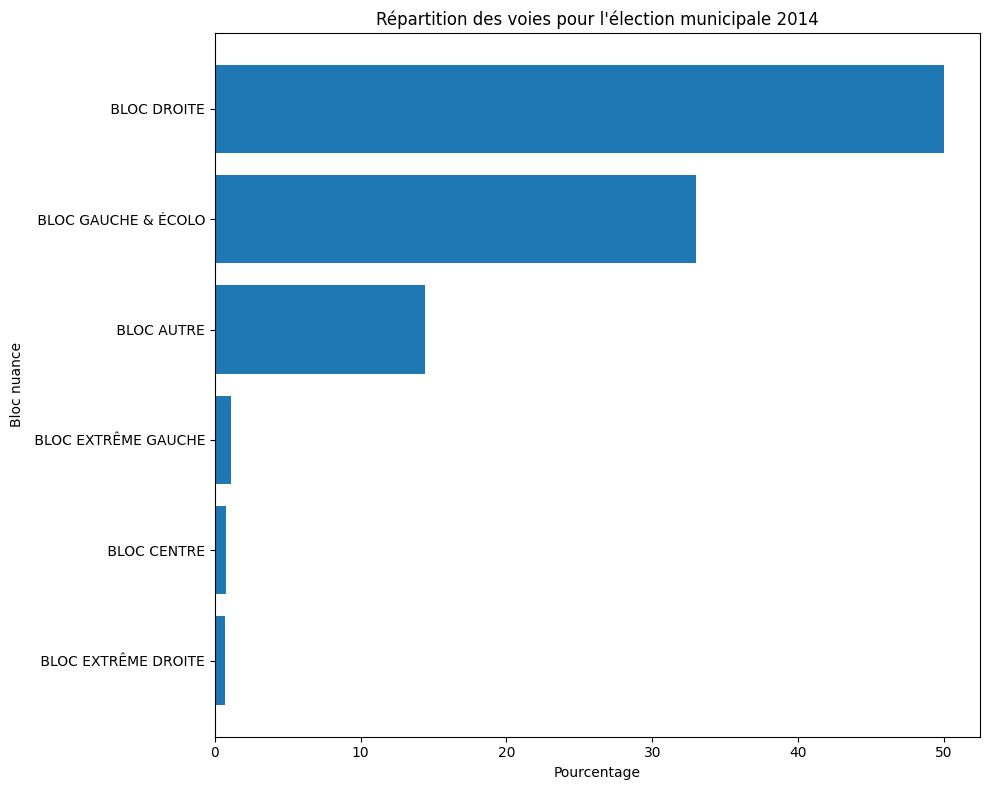

In [193]:
winners_2014["Bloc"] = winners_2014["Code Nuance"].map(nuance_to_bloc)
counts_2014 = (
    winners_2014
    .groupby("Bloc")
    .size()
    .pipe(lambda x: x / x.sum() * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(counts_2014.index, counts_2014.values, label="2014")

ax.set_xlabel("Pourcentage")
ax.set_ylabel("Bloc nuance")
ax.set_title("Répartition des voies pour l'élection municipale 2014")

plt.tight_layout()
plt.show()


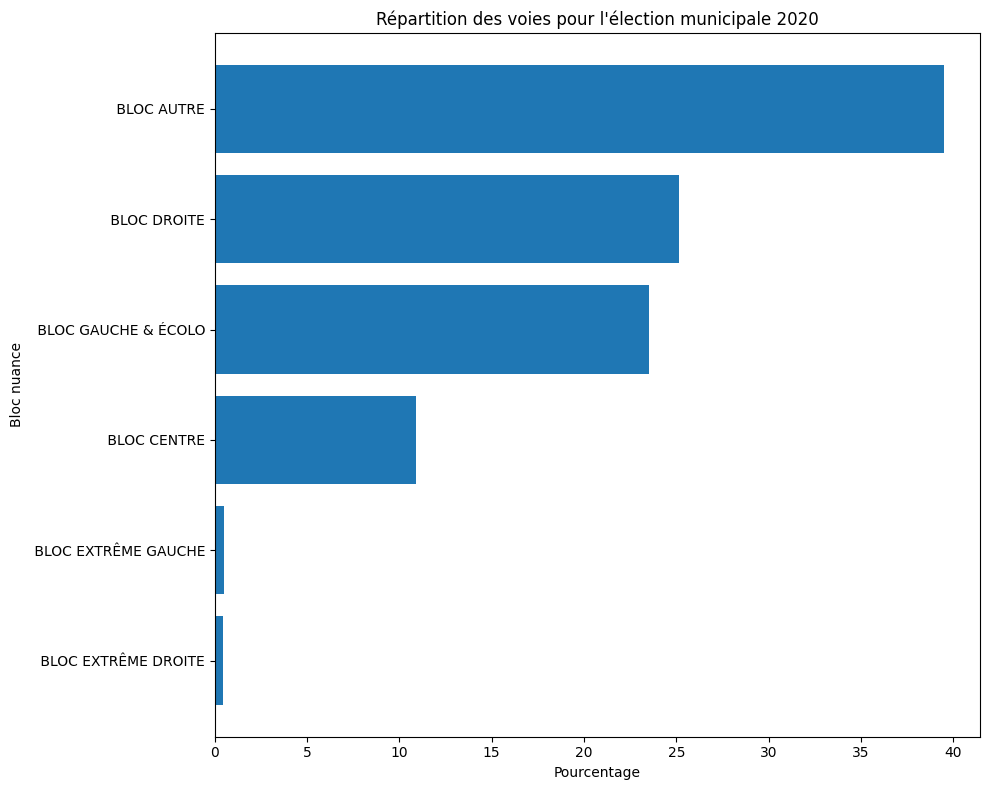

In [194]:
winners_2020["Bloc"] = winners_2020["Code Nuance"].map(nuance_to_bloc)
counts_2020 = (
    winners_2020
    .groupby("Bloc")
    .size()
    .pipe(lambda x: x / x.sum() * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(counts_2020.index, counts_2020.values)

ax.set_xlabel("Pourcentage")
ax.set_ylabel("Bloc nuance")
ax.set_title("Répartition des voies pour l'élection municipale 2020")

plt.tight_layout()
plt.show()

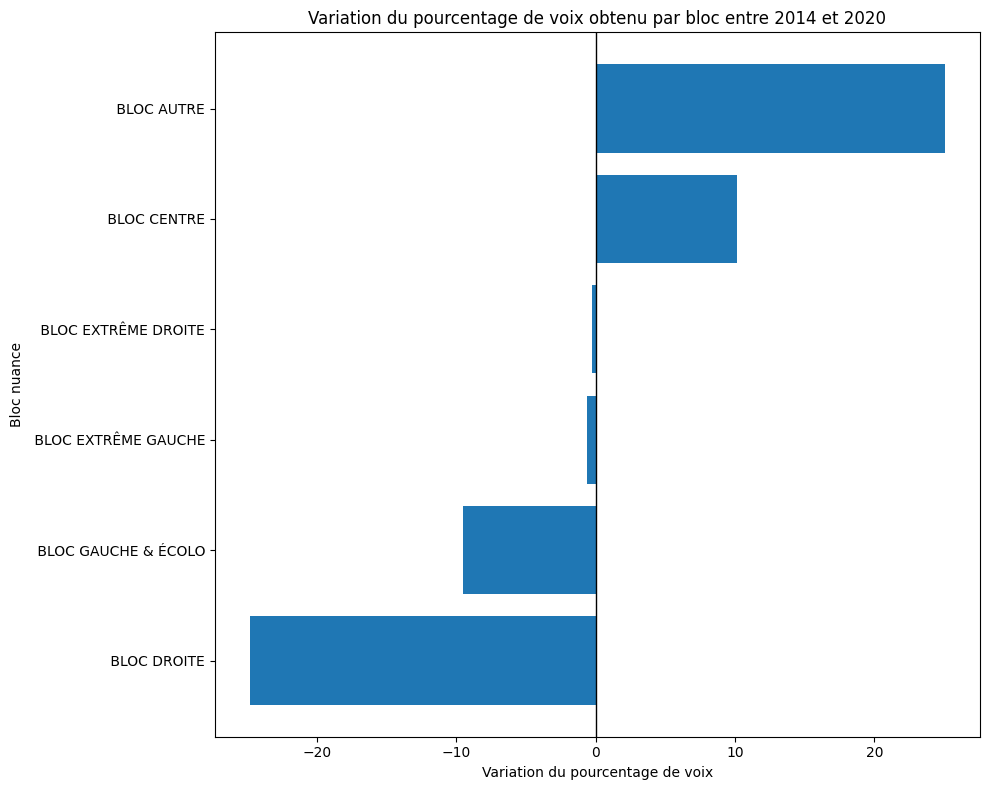

In [195]:
d_count = pd.concat([counts_2014, counts_2020], axis=1)
d_count.columns = ["2014", "2020"]
d_count = d_count.fillna(0)
d_count['Evol_percent'] = d_count['2020'] - d_count['2014']
d_count = d_count.sort_values(by=['Evol_percent'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(d_count.index, d_count['Evol_percent'])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Variation du pourcentage de voix")
ax.set_ylabel("Bloc nuance")
ax.set_title("Variation du pourcentage de voix obtenu par bloc entre 2014 et 2020")


plt.tight_layout()
plt.show()

La période entre 2014 et 2020 est marquée par une grande variations dans les listes présentées par les candidats aux élections municipales.

Lors de l'élection de 2014, le panel de candidat est dominé par les nuances traditionnelles "Divers Droite" et "Divers gauche". Au global, les nuances du bloc gauche et du bloc droite remporte près de 80% des communes de plus de 3 500 habitants.

En 2020, les résultats du bloc centre sont boostée par l'arrivée du partie LREM, qui participe à l'érosion des résultats du bloc de droite. Aussi, ce graphe rend compte de l'incomplétude nos données, car la forte progression du bloc autre s'explique en grande partie par l'accroissement significatif du nombre de communes n'ayant pas communiqué la nuance politique de leurs élus.

In [196]:
display(Markdown("""
#### Analyse de l'évolution de l'offre politique (2014-2020)

La période entre 2014 et 2020 est marquée par une grande variation dans les listes présentées par les candidats aux élections municipales.

* En 2014, le panel de candidats est dominé par les nuances traditionnelles ("Divers Droite" et "Divers Gauche"). Au global, les blocs de Gauche et de Droite remportent près de 80 % des communes de plus de 3 500 habitants.
* En 2020, les résultats du "Bloc Centre" sont portés par l'émergence de LREM, qui participe à l'érosion du Bloc de Droite. 
* Par ailleurs, la forte progression (relative) du "Bloc Autre" souligne une limite des données : elle s'explique en partie par l'augmentation significative du nombre de communes où la nuance politique n'a pas été clairement identifiée ou communiquée ("Nuances Neutres" ou "Divers").
"""))


#### Analyse de l'évolution de l'offre politique (2014-2020)

La période entre 2014 et 2020 est marquée par une grande variation dans les listes présentées par les candidats aux élections municipales.

* En 2014, le panel de candidats est dominé par les nuances traditionnelles ("Divers Droite" et "Divers Gauche"). Au global, les blocs de Gauche et de Droite remportent près de 80 % des communes de plus de 3 500 habitants.
* En 2020, les résultats du "Bloc Centre" sont portés par l'émergence de LREM, qui participe à l'érosion du Bloc de Droite. 
* Par ailleurs, la forte progression (relative) du "Bloc Autre" souligne une limite des données : elle s'explique en partie par l'augmentation significative du nombre de communes où la nuance politique n'a pas été clairement identifiée ou communiquée ("Nuances Neutres" ou "Divers").


### Résultats aux présidentielles 2022
Nous introduisons les données des 1ers tours des présidentielles de 2022 et 2017 par communes pour affiner notre analyse. Les code partis ne sont pas renseignés, seuls les candidats le sont. 

In [197]:
display(Markdown("""### Résultats de l'élection présidentielle 2022
Afin d'affiner notre analyse, nous introduisons ici les données du 1er tour de la présidentielle 2022 par commune.
L'objectif est de comparer le vote local (municipales) au vote national (présidentielles) sur les mêmes territoires.
A noter que les nuances politiques ne sont pas renseignés ; seuls les noms des candidats sont disponibles. Il faudra donc effectuer un mappage manuel pour les classer dans nos blocs politiques.
Des étapes de tri du vainqueur et de filtrage sont également nécessaires."""))

# --- 2. CHARGEMENT AVEC CHEMIN RELATIF ---
# Utilisation de la variable globale RAW_ELEC_DIR définie au début du notebook
file_path_pres_2022 = os.path.join(RAW_ELEC_DIR, 'Elections présidentielles 2022 par commune.xlsx')

print(f" Chargement du fichier : {os.path.basename(file_path_pres_2022)}...")

resultats_2022 = pd.read_excel(
    file_path_pres_2022, 
    header=0,
    # CRUCIAL : On force les codes en texte pour ne pas perdre les '0' (ex: Dept 01)
    dtype={'Code du département': str, 'Code de la commune': str} 
)
# --- 3. APERÇU ---
print(f"Chargement terminé : {len(resultats_2022)} lignes.")
display(resultats_2022.head(5))

### Résultats de l'élection présidentielle 2022
Afin d'affiner notre analyse, nous introduisons ici les données du 1er tour de la présidentielle 2022 par commune.
L'objectif est de comparer le vote local (municipales) au vote national (présidentielles) sur les mêmes territoires.
A noter que les nuances politiques ne sont pas renseignés ; seuls les noms des candidats sont disponibles. Il faudra donc effectuer un mappage manuel pour les classer dans nos blocs politiques.
Des étapes de tri du vainqueur et de filtrage sont également nécessaires.

 Chargement du fichier : Elections présidentielles 2022 par commune.xlsx...
Chargement terminé : 35245 lignes.


,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,...,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102
0,01,Ain,001,L'Abergement-Clémenciat,Complet,645,108,16.74,537,83.26,...,3,0.47,0.58,12,M,DUPONT-AIGNAN,Nicolas,21,3.26,4.04
1,01,Ain,002,L'Abergement-de-Varey,Complet,213,38,17.84,175,82.16,...,3,1.41,1.75,12,M,DUPONT-AIGNAN,Nicolas,0,0.00,0.00
2,01,Ain,004,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,76.29,...,43,0.49,0.66,12,M,DUPONT-AIGNAN,Nicolas,181,2.07,2.76
3,01,Ain,005,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,81.75,...,2,0.16,0.19,12,M,DUPONT-AIGNAN,Nicolas,27,2.11,2.63
4,01,Ain,006,Ambléon,Complet,103,23,22.33,80,77.67,...,0,0.00,0.00,12,M,DUPONT-AIGNAN,Nicolas,1,0.97,1.30


In [198]:
#On filtre d'abord les communes qui nous intéressent comme précédemment
df = pd.DataFrame(resultats_2022)
print(df['Code du département'].dtype)

df['Code du département'] = df['Code du département'].replace({'2A': '201', '2B': '202'})
resultats_2022['Code du département'] = pd.to_numeric(resultats_2022['Code du département'], errors='coerce')
resultats_2022 = resultats_2022[resultats_2022['Code du département'] < 900]


resultats_2022['Code commune'] = (
    resultats_2022['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2022['Code de la commune'].astype(str).str.zfill(3)
)

object


In [199]:
# Pour chaque commune, nous récupérons les résultats pour chacun des candidats

commune_cols_2022 = ['Code du département', 'Libellé du département', 'Code commune', 'Code de la commune',
'Libellé de la commune', 'Etat saisie', 'Inscrits', 'Abstentions','% Abs/Ins', 'Votants',	'% Vot/Ins', 'Blancs',	
 '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot'
]

candidate_fields_2022 = ["N°Panneau", "Sexe", "Nom", "Prénom", "Voix", "% Voix/Ins", "% Voix/Exp"
]
# Identification des blocs candidats et traitement pour chaque commune
cols_2022 = list(resultats_2022.columns)
start = cols_2022.index("N°Panneau") 
k = len(candidate_fields_2022)
nblocks = (len(cols) - start) // k

#On scinde par candidat pour ensuite isoler le vainqueur de l'élection à l'échelle communale
dfs = []
for b in range(nblocks):
    blk_cols = cols_2022[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2022[commune_cols_2022 + blk_cols].copy()
    cand_df.columns = commune_cols_2022 + candidate_fields_2022
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs.append(cand_df)

long_df_2022 = pd.concat(dfs, ignore_index=True)

long_df_2022_sorted_res = long_df_2022.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_2022_sorted = long_df_2022_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

df_clean = long_df_2022_sorted.drop(columns=['Code du département','Etat saisie', 'Inscrits', 'Abstentions','% Abs/Ins', 'Votants',	'% Vot/Ins', 'Blancs',	
 '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot'])


In [200]:

idx = long_df_2022_sorted.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df_2022_sorted["winner"] = "no"
long_df_2022_sorted.loc[idx, "winner"] = "yes"

long_df_2022_sorted_res = long_df_2022_sorted.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

# Créer un nouveau dataframe trié
df_trie = long_df_2022_sorted_res.sort_values(by=['Code commune', '% Voix/Exp'], ascending=[True, False])

# Afficher les 5 premières lignes pour vérifier
#df_trie.head(5)

In [201]:

df_work = long_df_2022_sorted.copy()

# Reset de l'index au début pour être sûr que idxmax renvoie des index valides
df_work = df_work.reset_index(drop=True)

# On trouve l'index de la ligne ayant le score max pour chaque commune
idx_winners = df_work.groupby("Code commune")["% Voix/Exp"].idxmax()

# On initialise la colonne à "no" partout
df_work["winner"] = "no"

# On passe à "yes" uniquement les lignes identifiées dans idx_winners
df_work.loc[idx_winners, "winner"] = "yes"

# On trie par 'Code commune' (croissant) 
# ET par '% Voix/Exp' (décroissant) pour que le gagnant soit toujours la 1ère ligne de la commune
df_final = df_work.sort_values(by=['Code commune', '% Voix/Exp'], ascending=[True, False])

# Affichage
df_final.head(10)

# On ne garde que les lignes où winner est égal à "yes"
df_vainqueurs = df_final[df_final["winner"] == "yes"].copy()
df_vainqueurs.drop(columns=["winner"], inplace=True)

# Vérification
#df_vainqueurs.head()

In [202]:
from IPython.display import display, Markdown
import os

# --- 1. CONTEXTE ET DICTIONNAIRE ---
display(Markdown("""
#### Harmonisation des nuances politiques (Présidentielle 2022)

Le fichier brut des présidentielles ne contient que les noms des candidats. Pour permettre la comparaison avec les élections municipales, nous devons attribuer manuellement à chaque candidat son code nuance administratif équivalent (ex: Macron = LREM, Mélenchon = LFI/LUG).

Nous créons une nouvelle colonne `code_nuance` en appliquant un dictionnaire de correspondance.
"""))

# Dictionnaire de mapping (candidat en code nuance admin)
parti_politique_map = {
    'MACRON': 'LREM',  
    'LE PEN': 'LFN',    
    'MÉLENCHON': 'LUG',  
    'ZEMMOUR': 'LEXD',
    'PÉCRESSE': 'LLR', 
    'JADOT': 'LVEC',
    'LASSALLE': 'LDVD',
    'ROUSSEL': 'LCOM',
    'DUPONT-AIGNAN': 'LDVD',
    'HIDALGO': 'LSOC',
    'POUTOU': 'LEXG',
    'ARTHAUD': 'LEXG'
}



df_vainqueurs['code_nuance'] = df_vainqueurs['Nom'].map(parti_politique_map)

display(Markdown("**Aperçu du résultat après attribution des nuances :**"))
display(df_vainqueurs[['Code commune', 'Nom', 'code_nuance', '% Voix/Exp']].head())


#### Harmonisation des nuances politiques (Présidentielle 2022)

Le fichier brut des présidentielles ne contient que les noms des candidats. Pour permettre la comparaison avec les élections municipales, nous devons attribuer manuellement à chaque candidat son code nuance administratif équivalent (ex: Macron = LREM, Mélenchon = LFI/LUG).

Nous créons une nouvelle colonne `code_nuance` en appliquant un dictionnaire de correspondance.


**Aperçu du résultat après attribution des nuances :**

,Code commune,Nom,code_nuance,% Voix/Exp
1,01001,MACRON,LREM,28.85
14,01002,MACRON,LREM,29.24
34,01004,LE PEN,LFN,25.12
46,01005,LE PEN,LFN,34.24
55,01006,MACRON,LREM,27.27


In [203]:
#Exportation
export_2022 = os.path.join(RAW_ELEC_DIR, 'elec_2022_pres_all.csv')
long_df_2022_sorted.to_csv(export_2022, index=False, sep=',', encoding='utf-8', na_rep='NA')


In [204]:
display(Markdown("""Enfin, cette base est exportée comme il se doit."""))

Enfin, cette base est exportée comme il se doit.

#### Statistiques descriptives sur les présidentielles de 2022

In [205]:
display(Markdown("""#### Statistiques descriptives sur les présidentielles de 2022"""))

#### Statistiques descriptives sur les présidentielles de 2022

In [206]:
display(Markdown("""Le graphique et le tableau ci-dessous montrent le nombre de communes où chaque candidat est arrivé en tête au 1er tour.
On observe une disparité importante entre les candidats : Marine Le Pen et Emmanuel Macron remportent à eux deux plus de 31 000 communes (91 % des communes étudiées ici) et certains candidats ne sont en tête que dans une poignée de villages (moins de 10 pour Jadot, Hidalgo, Arthaud, Poutou).

Nous utilisons une échelle logarithmique pour mieux visualiser les grandes des petites valeurs, rendant ainsi lisibles les ordres de grandeur de tous les candidats sur un même graphique.
"""))

Le graphique et le tableau ci-dessous montrent le nombre de communes où chaque candidat est arrivé en tête au 1er tour.
On observe une disparité importante entre les candidats : Marine Le Pen et Emmanuel Macron remportent à eux deux plus de 31 000 communes (91 % des communes étudiées ici) et certains candidats ne sont en tête que dans une poignée de villages (moins de 10 pour Jadot, Hidalgo, Arthaud, Poutou).

Nous utilisons une échelle logarithmique pour mieux visualiser les grandes des petites valeurs, rendant ainsi lisibles les ordres de grandeur de tous les candidats sur un même graphique.


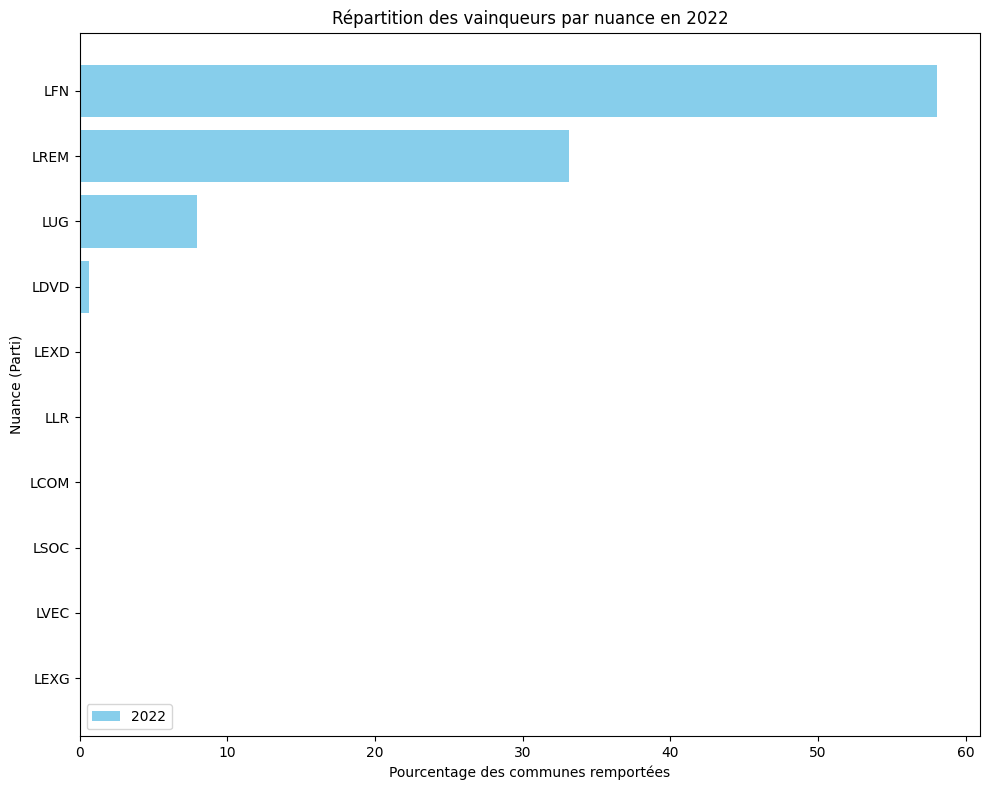

In [207]:
counts_2022 = df_vainqueurs['code_nuance'].value_counts(normalize=True) * 100 

# 2. Tri décroissant
counts_2022 = counts_2022.sort_values(ascending=True)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 8))

# Affichage des barres
ax.barh(counts_2022.index, counts_2022.values, label="2022", color='skyblue')

# 4. Habillage
ax.set_xlabel("Pourcentage des communes remportées")
ax.set_ylabel("Nuance (Parti)")
ax.set_title("Répartition des vainqueurs par nuance en 2022")
ax.legend()

plt.tight_layout()
plt.show()

In [208]:
# Calcul du nombre de communes gagnées par candidat
victoires_par_candidat = df_vainqueurs['Nom'].value_counts()

# Création d'un tableau
tableau_res = pd.DataFrame({
    'Candidat': victoires_par_candidat.index,
    'Nombre de Communes': victoires_par_candidat.values,
    'Pourcentage (%)': (victoires_par_candidat.values / len(df_vainqueurs) * 100).round(2)
})

# Ajout de la nuance
tableau_res['Nuance'] = tableau_res['Candidat'].map(parti_politique_map)

# Affichage
display(tableau_res)



,Candidat,Nombre de Communes,Pourcentage (%),Nuance
0,LE PEN,20011,58.07,LFN
1,MACRON,11417,33.13,LREM
2,MÉLENCHON,2732,7.93,LUG
3,LASSALLE,212,0.62,LDVD
4,ZEMMOUR,31,0.09,LEXD
5,PÉCRESSE,24,0.07,LLR
6,ROUSSEL,10,0.03,LCOM
7,HIDALGO,9,0.03,LSOC
8,JADOT,8,0.02,LVEC
9,DUPONT-AIGNAN,4,0.01,LDVD


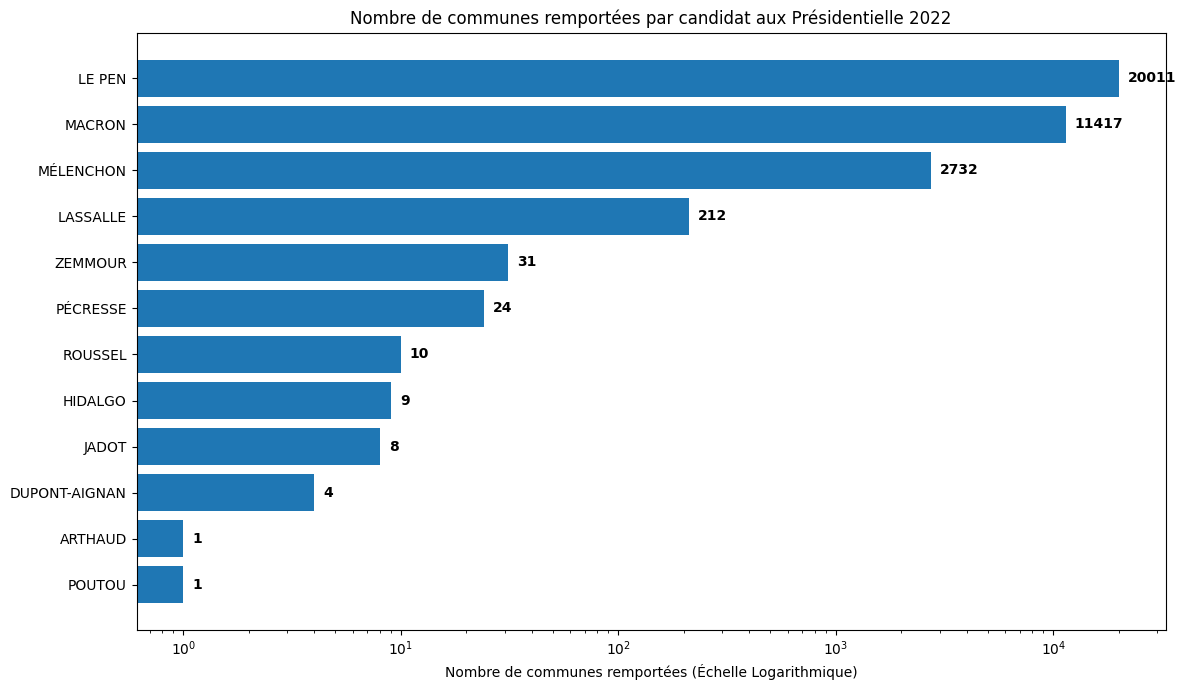

In [209]:
#On tente de faire ressortir sur un graphique à échelle logarithmique le nombre de villes par candidats
candidats = tableau_res['Candidat'].tolist()
valeurs = tableau_res['Nombre de Communes'].tolist()

fig, ax = plt.subplots(figsize=(12, 7))

# Création des barres
y_pos = np.arange(len(candidats))
ax.barh(y_pos, valeurs, align='center')

# --- Echelle Logarithmique ---
ax.set_xscale('log') 

# On ordonne dans l'ordre décroissant
ax.set_yticks(y_pos)
ax.set_yticklabels(candidats)
ax.invert_yaxis()  

ax.set_xlabel('Nombre de communes remportées (Échelle Logarithmique)')
ax.set_title('Nombre de communes remportées par candidat aux Présidentielle 2022')

#On ajoute les valeurs exactes de villes remportées après chacune des barres
for i, v in enumerate(valeurs):
    ax.text(v * 1.1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Ce graphique met en lumière une distorsion majeure entre la domination géographique et le résultat démographique final de l'élection de 2022. Bien que Marine Le Pen arrive en tête en remportant plus de 58 % des communes françaises (soit environ 20 011 communes), cela ne s'est pas traduit par une victoire en nombre de voix au niveau national. Pour autant, le front/rassemblement national ne remporte relativement que très peu des élections municipales. 

In [210]:
display(Markdown("""

Ce graphique met en lumière une distorsion majeure entre la domination territoriale et le poids démographique réel. 

1. Une domination en trompe-l'œil : Bien que Marine Le Pen arrive en tête dans plus de 58 % des communes (soit environ 20 011 communes), cela ne s'est pas traduit par une victoire nationale. Cela illustre la fracture de densité : gagner beaucoup de petits villages ne suffit pas face aux métropoles densément peuplées.
 
2. Le contraste avec l'ancrage local : Il existe un décalage frappant avec les élections municipales. Alors que le vote RN est massif aux présidentielles dans ces 20 000 communes, le Rassemblement National ne parvient paradoxalement à remporter que très peu de mairies. 
 
 Cela souligne la différence entre un vote de contestation/opinion nationale et la capacité d'un parti à structurer une offre politique locale (trouver des candidats, monter des listes crédibles) face à une offre locale déjà ancrée.
"""))



Ce graphique met en lumière une distorsion majeure entre la domination territoriale et le poids démographique réel. 

1. Une domination en trompe-l'œil : Bien que Marine Le Pen arrive en tête dans plus de 58 % des communes (soit environ 20 011 communes), cela ne s'est pas traduit par une victoire nationale. Cela illustre la fracture de densité : gagner beaucoup de petits villages ne suffit pas face aux métropoles densément peuplées.

2. Le contraste avec l'ancrage local : Il existe un décalage frappant avec les élections municipales. Alors que le vote RN est massif aux présidentielles dans ces 20 000 communes, le Rassemblement National ne parvient paradoxalement à remporter que très peu de mairies. 

 Cela souligne la différence entre un vote de contestation/opinion nationale et la capacité d'un parti à structurer une offre politique locale (trouver des candidats, monter des listes crédibles) face à une offre locale déjà ancrée.


### Elections présidentielles de 2017


In [211]:
# --- 1. CONTEXTE (Markdown) ---
display(Markdown("""
### Elections présidentielle de 2017

Nous intégrons également les résultats du 1er tour de 2017 pour analyser la dynamique électorale sur un temps plus long.
Le traitement suit la même logique que pour 2022 : nettoyage géographique, restructuration des données pour isoler le vainqueur par commune et harmonisation des nuances politiques.
"""))


### Elections présidentielle de 2017

Nous intégrons également les résultats du 1er tour de 2017 pour analyser la dynamique électorale sur un temps plus long.
Le traitement suit la même logique que pour 2022 : nettoyage géographique, restructuration des données pour isoler le vainqueur par commune et harmonisation des nuances politiques.


In [212]:
# Chemin relatif robuste
file_path_2017 = os.path.join(RAW_ELEC_DIR, 'Presidentielle_2017_Resultats_Communes_Tour_1_c.xls')

print("Chargement des données 2017...")
resultats_2017 = pd.read_excel(file_path_2017, header=3, dtype=str)

Chargement des données 2017...


In [213]:
# Nettoyage (Gestion de la Corse et filtrage Métropole)
resultats_2017['Code du département'] = resultats_2017['Code du département'].replace({'2A': '201', '2B': '202'})
resultats_2017['Code du département'] = pd.to_numeric(resultats_2017['Code du département'], errors='coerce')
resultats_2017 = resultats_2017[resultats_2017['Code du département'] < 900].copy()

# Création d'un code commune unique
resultats_2017['Code commune'] = (
    resultats_2017['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2017['Code de la commune'].astype(str).str.zfill(3)
)

In [214]:
# Définition des colonnes de base
commune_cols_2017 = [
    'Code du département', 'Libellé du département', 'Code commune', 'Code de la commune',
    'Libellé de la commune', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', 'Exprimés'
]

# Colonnes répétés pour chaque candidat 
candidate_fields_2017 = ["N°Panneau", "Sexe", "Nom", "Prénom", "Voix", "% Voix/Ins", "% Voix/Exp"]

cols_2017 = list(resultats_2017.columns)
# On identifie l'index de la première colonne "N°Panneau"
debut_candidats = cols_2017.index("N°Panneau") 
k = len(candidate_fields_2017)
nombre_candidats = (len(cols_2017) - debut_candidats) // k

dfs_2017 = []
for i in range(nombre_candidats):
    debut = debut_candidats + i * k
    fin = debut + k
    blk_cols = cols_2017[debut:fin]
    
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2017[commune_cols_2017 + blk_cols].copy()
    cand_df.columns = commune_cols_2017 + candidate_fields_2017
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs_2017.append(cand_df)

long_df_2017 = pd.concat(dfs_2017, ignore_index=True)


In [215]:

# On remplace la virgule par le point pour permettre la conversion numérique
long_df_2017['% Voix/Exp'] = pd.to_numeric(
    long_df_2017['% Voix/Exp'].astype(str).str.replace(',', '.'), 
    errors='coerce'
)
df_work_2017 = long_df_2017.reset_index(drop=True)

# On trouve l'index du score max par commune
idx_winners_2017 = df_work_2017.groupby("Code commune")["% Voix/Exp"].idxmax()

# Initialisation et marquage
df_work_2017["winner"] = "no"
df_work_2017.loc[idx_winners_2017, "winner"] = "yes"

# Extraction des vainqueurs
df_vainqueurs_2017 = df_work_2017[df_work_2017["winner"] == "yes"].copy()
df_vainqueurs_2017.drop(columns=["winner"], inplace=True)


In [216]:

# Mapping des nuances 
Parti_politique_2017 = {
    'MACRON': 'LREM',
    'LE PEN': 'LFN',
    'MÉLENCHON': 'LUG',
    'FILLON': 'LLR',
    'HAMON': 'LSOC',
    'DUPONT-AIGNAN': 'LDVD',
    'LASSALLE': 'LDVD',
    'ASSELINEAU': 'LDVD',
    'ROUSSEL': 'LCOM',
    'POUTOU': 'LEXG',
    'ARTHAUD': 'LEXG',
    'CHEMINADE': 'LDVD'
}
df_vainqueurs_2017['code_nuance'] = df_vainqueurs_2017['Nom'].str.upper().map(Parti_politique_2017)
display(Markdown("""
#### Aperçu des données traitées

Voici un extrait de la base de données finale pour 2017
"""))
display(df_vainqueurs_2017[['Code commune', 'Nom', 'code_nuance', '% Voix/Exp']].head())


#### Aperçu des données traitées

Voici un extrait de la base de données finale pour 2017


,Code commune,Nom,code_nuance,% Voix/Exp
0,01001,LE PEN,LFN,25.45
1,01002,LE PEN,LFN,27.27
2,01004,LE PEN,LFN,25.84
3,01005,LE PEN,LFN,32.80
4,01006,MÉLENCHON,LUG,24.68


In [217]:
export_2017 = os.path.join(RAW_ELEC_DIR, 'elec_2017_pres_all.csv')
long_df_2017.to_csv(export_2017, index=False, sep=',', encoding='utf-8', na_rep='NA')

In [218]:
display(Markdown("""Les données sont bien exportées."""))

Les données sont bien exportées.

#### Statistiques descriptives sur les présidentielles de 2017

In [219]:

print(f"Nombre de communes traitées en 2017 : {len(df_vainqueurs_2017)}")
display(df_vainqueurs_2017.head())

Nombre de communes traitées en 2017 : 35281


,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,Exprimés,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,code_nuance
0,1.0,Ain,01001,1,L'Abergement-Clémenciat,598,92,15.38,506,495,2,F,LE PEN,Marine,126,21.07,25.45,LFN
1,1.0,Ain,01002,2,L'Abergement-de-Varey,209,25,11.96,184,176,2,F,LE PEN,Marine,48,22.97,27.27,LFN
2,1.0,Ain,01004,4,Ambérieu-en-Bugey,8586,1962,22.85,6624,6452,2,F,LE PEN,Marine,1667,19.42,25.84,LFN
3,1.0,Ain,01005,5,Ambérieux-en-Dombes,1172,215,18.34,957,933,2,F,LE PEN,Marine,306,26.11,32.80,LFN
4,1.0,Ain,01006,6,Ambléon,99,20,20.2,79,77,9,M,MÉLENCHON,Jean-Luc,19,19.19,24.68,LUG


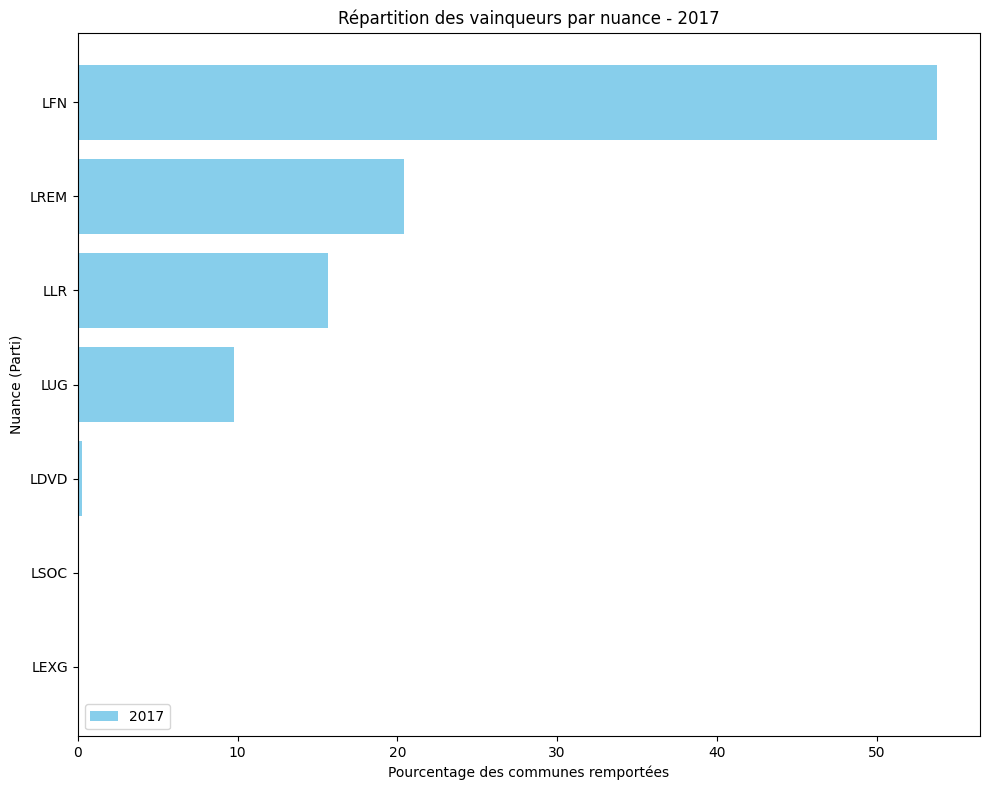

In [220]:
counts_2017 = df_vainqueurs_2017['code_nuance'].value_counts(normalize=True) * 100 

# 2. Tri décroissant
counts_2017 = counts_2017.sort_values(ascending=True)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 8))

# Affichage des barres
ax.barh(counts_2017.index, counts_2017.values, label="2017", color='skyblue')

# 4. Habillage
ax.set_xlabel("Pourcentage des communes remportées")
ax.set_ylabel("Nuance (Parti)")
ax.set_title("Répartition des vainqueurs par nuance - 2017")
ax.legend()

plt.tight_layout()
plt.show()

In [221]:
# Affichage des noms uniques pour vérification
print("Candidats identifiés en 2017 :", df_vainqueurs_2017['Nom'].unique())

# Calcul du nombre de communes gagnées par candidat
victoires_2017 = df_vainqueurs_2017['Nom'].value_counts()

# Création du tableau de bord propre
tableau_res_2017 = pd.DataFrame({
    'Candidat': victoires_2017.index,
    'Nombre de Communes': victoires_2017.values,
    'Pourcentage (%)': (victoires_2017.values / len(df_vainqueurs_2017) * 100).round(2)
})

# Ajout de la nuance via le dictionnaire Parti_politique_2017 défini plus haut
tableau_res_2017['Nuance'] = tableau_res_2017['Candidat'].map(Parti_politique_2017)

print(f"Total des communes traitées (2017) : {len(df_vainqueurs_2017)}")
display(tableau_res_2017)

Candidats identifiés en 2017 : ['LE PEN' 'MÉLENCHON' 'MACRON' 'FILLON' 'DUPONT-AIGNAN' 'LASSALLE' 'HAMON'
 'ASSELINEAU' 'POUTOU']
Total des communes traitées (2017) : 35281


,Candidat,Nombre de Communes,Pourcentage (%),Nuance
0,LE PEN,18973,53.78,LFN
1,MACRON,7213,20.44,LREM
2,FILLON,5530,15.67,LLR
3,MÉLENCHON,3446,9.77,LUG
4,LASSALLE,78,0.22,LDVD
5,DUPONT-AIGNAN,23,0.07,LDVD
6,HAMON,16,0.05,LSOC
7,ASSELINEAU,1,0.00,LDVD
8,POUTOU,1,0.00,LEXG


In [222]:

display(Markdown("""Pour une meilleur lisibilité, l'histogramme de la répartition des vainqueurs est représenté en échelle logarithmique :"""))

Pour une meilleur lisibilité, l'histogramme de la répartition des vainqueurs est représenté en échelle logarithmique :

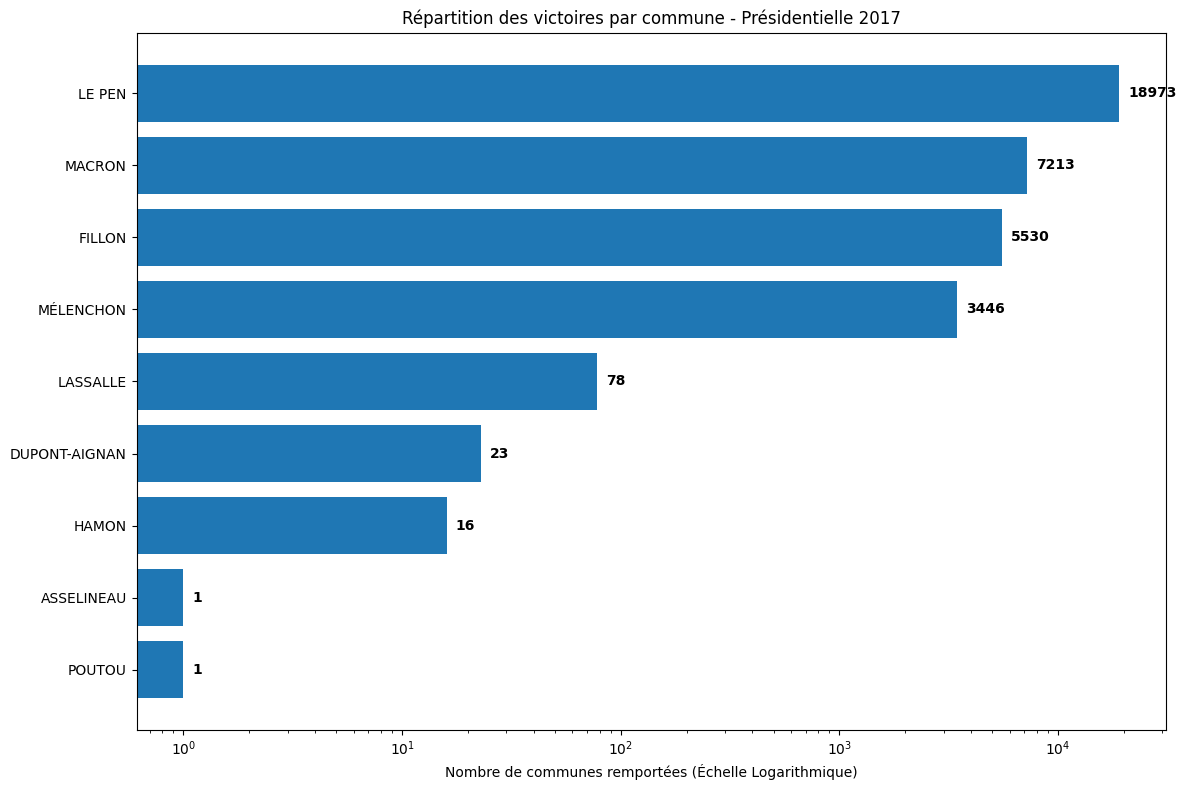

In [223]:
candidats_17 = tableau_res_2017['Candidat'].tolist()
valeurs_17 = tableau_res_2017['Nombre de Communes'].tolist()
nuances_17 = tableau_res_2017['Nuance'].tolist()

fig, ax = plt.subplots(figsize=(12, 8))

# Création des barres horizontales
y_pos = np.arange(len(candidats_17))
ax.barh(y_pos, valeurs_17, align='center')

# --- Échelle Logarithmique ---
# Indispensable pour voir les candidats à faible score (Arthaud/Cheminade) à côté des gros
ax.set_xscale('log') 

# Configuration des axes
ax.set_yticks(y_pos)
ax.set_yticklabels(candidats_17)
ax.invert_yaxis() # Le vainqueur (Le Pen ou Macron selon 2017) en haut

ax.set_xlabel('Nombre de communes remportées (Échelle Logarithmique)')
ax.set_title('Répartition des victoires par commune - Présidentielle 2017')

# Ajout des valeurs exactes après chaque barre
for i, v in enumerate(valeurs_17):
    ax.text(v * 1.1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [224]:
display(Markdown("""Les graphiques ci-dessus révèlent une configuration politique qui préfigure la recomposition de 2022 :

1.  L'hégémonie géographique du Front National (LFN) :
    * Tout comme en 2022, Marine Le Pen domine la carte des communes, arrivant en tête dans près de **19 000 localités** (soit plus de 53 % des communes françaises).

2.  La résistance de la Droite (Fillon) et l'effondrement de la Gauche (Hamon) :
    * François Fillon conserve une assise territoriale forte (3ème force,  près de5 500 communes), montrant que l'ancrage local de la droite traditionnelle résistait encore en 2017.
    * À l'inverse, le Parti Socialiste (Benoît Hamon) disparaît presque totalement de la carte des vainqueurs (moins de 20 communes), supplanté par Jean-Luc Mélenchon (LUG/LFI) qui capte le vote de gauche urbain et contestataire (environ 3 500 communes).

3.  La géographie spécifique du "Macronisme" naissant :
    * Emmanuel Macron remporte environ 7 200 communes. Moins étendu géographiquement que le vote Le Pen, son électorat est plus efficace démographiquement (villes moyennes et grandes), ce qui lui permet de virer en tête au niveau national.

"""))

Les graphiques ci-dessus révèlent une configuration politique qui préfigure la recomposition de 2022 :

1.  L'hégémonie géographique du Front National (LFN) :
    * Tout comme en 2022, Marine Le Pen domine la carte des communes, arrivant en tête dans près de **19 000 localités** (soit plus de 53 % des communes françaises).

2.  La résistance de la Droite (Fillon) et l'effondrement de la Gauche (Hamon) :
    * François Fillon conserve une assise territoriale forte (3ème force,  près de5 500 communes), montrant que l'ancrage local de la droite traditionnelle résistait encore en 2017.
    * À l'inverse, le Parti Socialiste (Benoît Hamon) disparaît presque totalement de la carte des vainqueurs (moins de 20 communes), supplanté par Jean-Luc Mélenchon (LUG/LFI) qui capte le vote de gauche urbain et contestataire (environ 3 500 communes).

3.  La géographie spécifique du "Macronisme" naissant :
    * Emmanuel Macron remporte environ 7 200 communes. Moins étendu géographiquement que le vote Le Pen, son électorat est plus efficace démographiquement (villes moyennes et grandes), ce qui lui permet de virer en tête au niveau national.



In [225]:
display(Markdown("""####Comparaison entre les résultats de 2017 et 2022 via une matrice des corrélations"""))

####Comparaison entre les résultats de 2017 et 2022 via une matrice des corrélations

Nombre de communes comparées : 34458


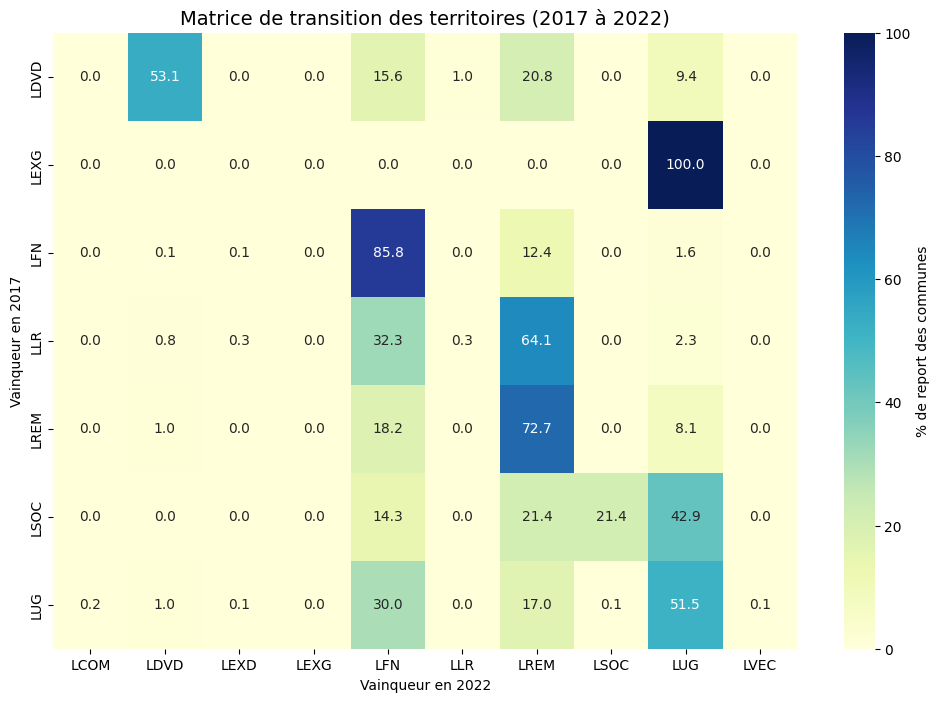

In [226]:

# On crée des DataFrames
# On garde le 'Code commune' et on ajoute la nuance politique adaptée
w17 = df_vainqueurs_2017[['Code commune']].copy()
w17['Vainqueur_2017'] = df_vainqueurs_2017['Nom'].str.upper().map(Parti_politique_2017).fillna('AUTRE')

w22 = df_vainqueurs[['Code commune']].copy()
w22['Vainqueur_2022'] = df_vainqueurs['Nom'].str.upper().map(parti_politique_map).fillna('AUTRE')

# On effectue une fusion des 2 DataFrames
comparison_df = w17.merge(w22, on='Code commune', how='inner')

if not comparison_df.empty:
    print(f"Nombre de communes comparées : {len(comparison_df)}")

# Matrice de transition
    transition_matrix = pd.crosstab(
        comparison_df['Vainqueur_2017'], 
        comparison_df['Vainqueur_2022'], 
        normalize='index'
    ) * 100

# Affichage
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        transition_matrix, 
        annot=True, 
        fmt=".1f", 
        cmap="YlGnBu", 
        cbar_kws={'label': '% de report des communes'}
    )
    plt.title("Matrice de transition des territoires (2017 à 2022)", fontsize=14)
    plt.ylabel("Vainqueur en 2017")
    plt.xlabel("Vainqueur en 2022")
    plt.show()
else:
    print("Erreur : Aucune commune commune trouvée entre les deux bases.")

In [227]:
display(Markdown("""La matrice de transition ci-dessus permet de visualiser la **fidélité** des territoires et les **reports de voix** d'une élection à l'autre. Trois phénomènes sont observables :

1.  La rigidité du Rassemblement National (LFN) :
    * Le RN affiche le taux de fidélité le plus important : **85.8 %** des communes remportées par Marine Le Pen en 2017 ont de nouveau voté pour elle en 2022.
    * C'est un électorat territorialement extrêmement stable. Les pertes sont minimes (12.4% vers LREM), confirmant que les bastions conquis en 2017 sont restés ancrés à l'extrême droite.

2.  L'absorption de la Droite Républicaine (LLR) :
    * C'est le fait le plus marquant de la recomposition. Les communes gagnées par François Fillon (LLR) en 2017 ont littéralement disparu au profit des deux finalistes.
    * **64.1 %** de ces communes ont basculé vers **Emmanuel Macron (LREM)**.
    * **32.3 %** ont basculé vers **Marine Le Pen (LFN)**.
    * Cela illustre l'écartèlement de l'électorat de droite, absorbé par le centre ou l'extrême droite, ne laissant presque aucune commune à Valérie Pécresse en 2022.

3.  La "porosité" du vote contestataire (LUG -> LFN) :
    * Concernant les communes remportées par Jean-Luc Mélenchon en 2017 (LUG) si **51.5 %** restent fidèles à la gauche radicale (LFI), une part très importante (**30.0 %**) a basculé vers le **Rassemblement National (LFN)**.
    * Ce chiffre illustre, à l'échelle locale, la théorie des "vases communicants" du vote de colère dans les zones périurbaines ou désindustrialisées : quand la gauche recule, c'est souvent le RN qui en profite directement, plutôt que le centre.

4.  La consolidation du Bloc Central (LREM) :
    * Emmanuel Macron conserve **72.7 %** de ses conquêtes de 2017.
    * Cependant, il cède du terrain sur sa droite : **18.2 %** des communes qu'il avait gagnées en 2017 ont basculé vers Marine Le Pen en 2022, signe d'une radicalisation de certains territoires modérés ou d'une déception vis-à-vis du pouvoir en place.

**Conclusion :** Cette matrice confirme la disparition du clivage Gauche/Droite traditionnel au profit d'une **bipolarisation territoriale** entre le Bloc Central (qui a absorbé la droite classique) et le Bloc Nationaliste (qui s'enracine et grignote sur les terres de la gauche contestataire).
"""))

La matrice de transition ci-dessus permet de visualiser la **fidélité** des territoires et les **reports de voix** d'une élection à l'autre. Trois phénomènes sont observables :

1.  La rigidité du Rassemblement National (LFN) :
    * Le RN affiche le taux de fidélité le plus important : **85.8 %** des communes remportées par Marine Le Pen en 2017 ont de nouveau voté pour elle en 2022.
    * C'est un électorat territorialement extrêmement stable. Les pertes sont minimes (12.4% vers LREM), confirmant que les bastions conquis en 2017 sont restés ancrés à l'extrême droite.

2.  L'absorption de la Droite Républicaine (LLR) :
    * C'est le fait le plus marquant de la recomposition. Les communes gagnées par François Fillon (LLR) en 2017 ont littéralement disparu au profit des deux finalistes.
    * **64.1 %** de ces communes ont basculé vers **Emmanuel Macron (LREM)**.
    * **32.3 %** ont basculé vers **Marine Le Pen (LFN)**.
    * Cela illustre l'écartèlement de l'électorat de droite, absorbé par le centre ou l'extrême droite, ne laissant presque aucune commune à Valérie Pécresse en 2022.

3.  La "porosité" du vote contestataire (LUG -> LFN) :
    * Concernant les communes remportées par Jean-Luc Mélenchon en 2017 (LUG) si **51.5 %** restent fidèles à la gauche radicale (LFI), une part très importante (**30.0 %**) a basculé vers le **Rassemblement National (LFN)**.
    * Ce chiffre illustre, à l'échelle locale, la théorie des "vases communicants" du vote de colère dans les zones périurbaines ou désindustrialisées : quand la gauche recule, c'est souvent le RN qui en profite directement, plutôt que le centre.

4.  La consolidation du Bloc Central (LREM) :
    * Emmanuel Macron conserve **72.7 %** de ses conquêtes de 2017.
    * Cependant, il cède du terrain sur sa droite : **18.2 %** des communes qu'il avait gagnées en 2017 ont basculé vers Marine Le Pen en 2022, signe d'une radicalisation de certains territoires modérés ou d'une déception vis-à-vis du pouvoir en place.

**Conclusion :** Cette matrice confirme la disparition du clivage Gauche/Droite traditionnel au profit d'une **bipolarisation territoriale** entre le Bloc Central (qui a absorbé la droite classique) et le Bloc Nationaliste (qui s'enracine et grignote sur les terres de la gauche contestataire).


In [ ]:
display(Markdown("""#### Influence de l'étiquette du maire élu en 2020 sur les résultats de l'élection de 2022"""))

### Influence de l'étiquette du maire élu en 2020 sur les résultats de l'élection de 2022

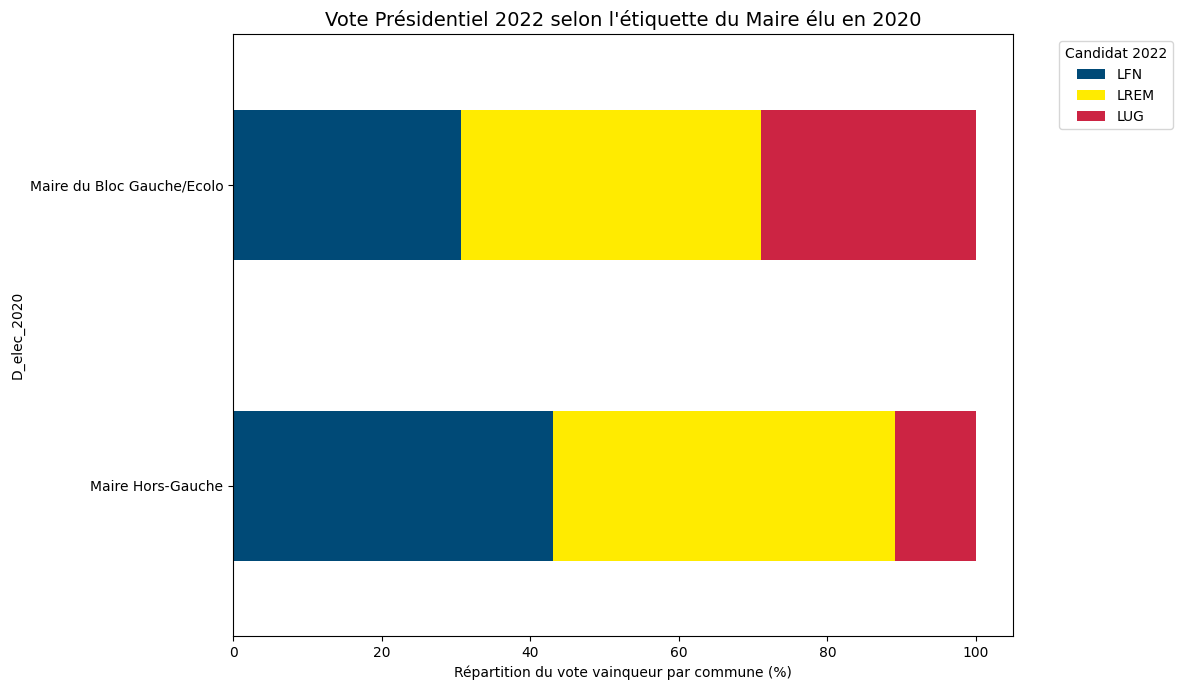

In [229]:

# Préparation et fusion des bases 2020 et 2022
df_croisement = pd.merge(
    winners_2020[['Code commune', 'D_elec_2020']], 
    df_vainqueurs[['Code commune', 'Nom', 'code_nuance']], 
    on='Code commune'
)

# Création d'un pivot pour compter les vainqueurs 2022 selon l'orientation de la commune en 2020
# 0 = Maire de Droite/Centre/Autre, 1 = Maire du Bloc Gauche/Ecolo
analyse_pivot = df_croisement.groupby(['D_elec_2020', 'code_nuance']).size().unstack(fill_value=0)

# Normalisation
analyse_pct = analyse_pivot.div(analyse_pivot.sum(axis=1), axis=0) * 100

# Visualisation
fig, ax = plt.subplots(figsize=(12, 7))

# Couleurs pour les nuances 2022
couleurs_2022 = {
    'LFN': '#004a77', 'LREM': '#ffeb00', 'LUG': '#cc2443', 
    'LDVD': '#aab1b7', 'LLR': '#0066cc', 'LCOM': '#dd0000'
}

analyse_pct.plot(kind='barh', stacked=True, ax=ax, color=[couleurs_2022.get(c, '#333333') for c in analyse_pct.columns])

# Légendes et titre
ax.set_title("Vote Présidentiel 2022 selon l'étiquette du Maire élu en 2020", fontsize=14)
ax.set_yticklabels(['Maire Hors-Gauche', 'Maire du Bloc Gauche/Ecolo'])
ax.set_xlabel("Répartition du vote vainqueur par commune (%)")
plt.legend(title="Candidat 2022", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [230]:
display(Markdown("""Ce graphique met en exergue une corrélation politique entre la couleur politique de la mairie 
(élue en 2020) et le comportement électoral lors de la présidentielle 2022. 

On observe une polarisation des territoires : les communes dirigées par le **Bloc Gauche/Écolo** agissent comme des **bastions** tout en jouant un rôle de "digue" freinant significativement le vote pour l'extrême droite. 

À l'opposé, les communes gérées par des maires **"Hors-Gauche"** (Droite, Centre ou Sans Étiquette) plébiscitent bien plus le Rassemblement National, tandis que le vote de gauche s'y effondre. Au centre de cette fracture territoriale, 
le vote Macron (LREM) fait figure de **constante**, conservant une base électorale solide et transversalement stable quelle que soit l'étiquette du maire.
"""))

Ce graphique met en exergue une corrélation politique entre la couleur politique de la mairie 
(élue en 2020) et le comportement électoral lors de la présidentielle 2022. 

On observe une polarisation des territoires : les communes dirigées par le **Bloc Gauche/Écolo** agissent comme des **bastions** tout en jouant un rôle de "digue" freinant significativement le vote pour l'extrême droite. 

À l'opposé, les communes gérées par des maires **"Hors-Gauche"** (Droite, Centre ou Sans Étiquette) plébiscitent bien plus le Rassemblement National, tandis que le vote de gauche s'y effondre. Au centre de cette fracture territoriale, 
le vote Macron (LREM) fait figure de **constante**, conservant une base électorale solide et transversalement stable quelle que soit l'étiquette du maire.
